**Block 1: Setup & Imports**

In [7]:
# Install required libraries
!pip install python-docx scikit-learn seaborn matplotlib pandas numpy -q
!apt-get update -qq && apt-get install -y libreoffice -qq

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

import docx
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from google.colab import files

sns.set_theme(style="whitegrid")
print("Environment configured successfully.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Environment configured successfully.


**Block 2: Data Preprocessing & Pipeline Construction**

In [8]:
# Load dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Define feature subsets
features_num = ['Age', 'Fare', 'SibSp', 'Parch']
features_cat = ['Pclass', 'Sex', 'Embarked']
target = 'Survived'

X = df[features_num + features_cat]
y = df[target]

# Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Numeric pipeline: Median imputation + Standard Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Frequent imputation + One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, features_num),
    ('cat', cat_transformer, features_cat)
])

print("Data preprocessing pipeline created successfully.")

Data preprocessing pipeline created successfully.


**Block 3: Model Training & Evaluation**

In [9]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train model
    clf_pipeline.fit(X_train, y_train)

    # Predict
    y_pred = clf_pipeline.predict(X_test)
    y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'pipeline': clf_pipeline,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'metrics': {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}
    }

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

--- Logistic Regression ---
Accuracy: 0.8045 | Precision: 0.7931 | Recall: 0.6667 | F1: 0.7244 | AUC: 0.8427
--- Decision Tree ---
Accuracy: 0.7765 | Precision: 0.7544 | Recall: 0.6232 | F1: 0.6825 | AUC: 0.7927
--- Random Forest ---
Accuracy: 0.8156 | Precision: 0.8000 | Recall: 0.6957 | F1: 0.7442 | AUC: 0.8345


**Block 4: Required Visualizations (Confusion Matrix & ROC Curves)**

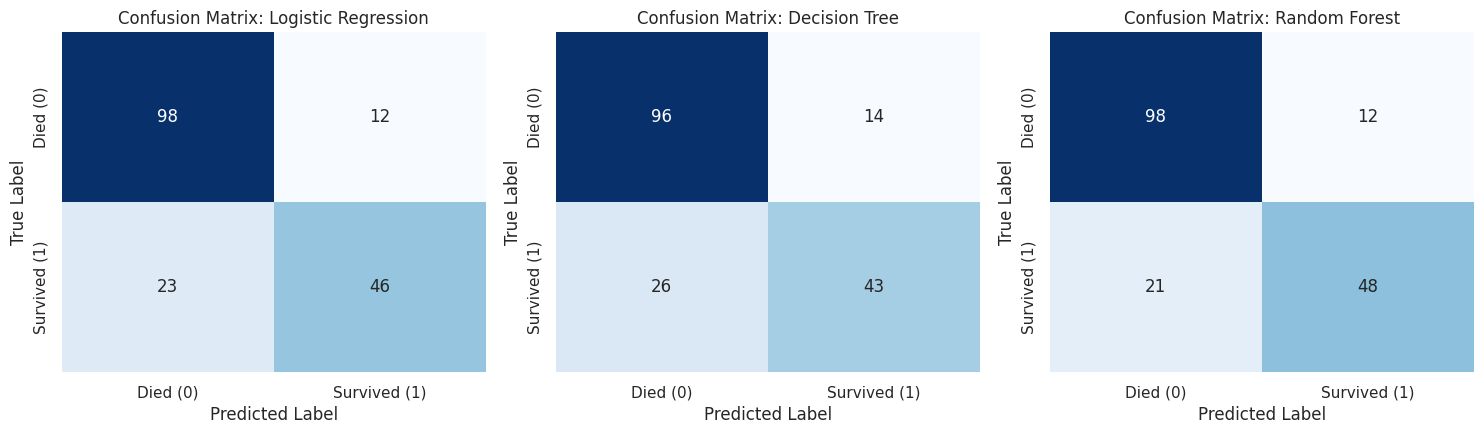

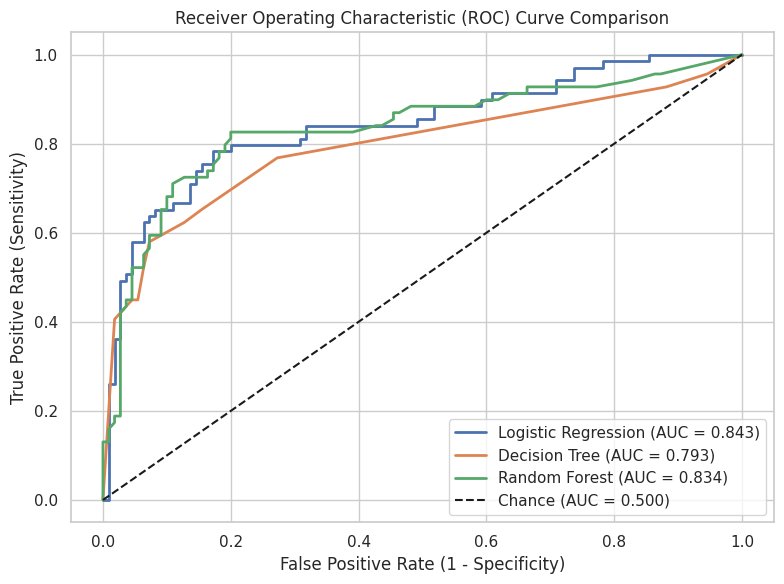

In [10]:
# Visual 1: Confusion Matrices Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['Died (0)', 'Survived (1)'])
    axes[idx].set_yticklabels(['Died (0)', 'Survived (1)'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

# Visual 2: Comparative ROC Curves
plt.figure(figsize=(8, 6))
from sklearn.metrics import roc_curve

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc_val = res['metrics']['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.500)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)
plt.show()